## Data Preparation

In [275]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.mixture import GaussianMixture
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [276]:
#load upstream results
ss = pd.read_csv('similarity_features.csv')
ner = pd.read_csv('NER.csv')
nli = pd.read_csv('fact_check_results.csv')
tm = pd.read_csv('topic_assignments.csv')

In [277]:
#merge results from the four upstream models
ss = ss.rename(columns={'reference_text': 'reference', 'output_text': 'output'})
result = pd.merge(ss, ner, on = ['reference', 'output'])

result2 = pd.merge(result, nli, on = ['reference', 'output'])

tm = tm.rename(columns = {'Document': 'reference'})
merged = pd.merge(result2, tm)
merged.drop_duplicates(inplace=True)
merged.shape

(7941, 30)

In [278]:
#one hot encode topic ("Name") column
encoded = pd.get_dummies(
    merged,
    columns=['Name'],
    drop_first=True,
    dtype = int
)

encoded = encoded.rename(columns={'Name_Business': 'Business',
                              'Name_Finance': 'Finance',
                              'Name_Health': 'Health',
                              'Name_Law': 'Law',
                              'Name_Science': 'Science',
                              'Name_Technology': 'Technology'})

#change target variable to 0/1
encoded['label'] = encoded['label'].map({'hallucinated': 1, 'factual': 0})

In [279]:
#drop and reorder columns
final = encoded.drop(columns=['ground_truth_label', 'input', 'verdict', 'confidence', 'moderation',
                             'nli_prediction', 'Topic', 'Representation', 'Representative_Docs',
                             'Top_n_words', 'Representative_document'])

final = final[['reference', 'output', 'global_cosine', 'min_window_cosine', 'euclidean_dist', 'length_ratio', 'char_length_diff',
              'Entity Recall', 'Out-Of-Reference Rate', 'Number Overlap', 'contradiction', 'entailment', 'neutral', 
              'Business', 'Finance', 'Health', 'Law', 'Science', 'Technology', 'Probability',
              'label', 'hallucination_type_realized', 'question_type', 'hallucination_type_encouraged']]



In [280]:
#create a df with only the features relevant to model fit 
#(leave out things like question or hallucination type; but may be used in evaluation later)
model_df = final[['global_cosine', 'min_window_cosine', 'euclidean_dist', 'length_ratio', 'char_length_diff', #sentence similarity features
                 'Entity Recall', 'Out-Of-Reference Rate', 'Number Overlap', #NER features 
                 'contradiction', 'entailment', 'neutral', #NLI features
                 'Business', 'Finance', 'Health', 'Law', 'Science', 'Technology', 'Probability', #BERTopic topic modeling features
                 'label']] #target

features = model_df.iloc[:, :-1]
labels = model_df['label']

## Model Fitting

In [281]:
features.head()

,global_cosine,min_window_cosine,euclidean_dist,length_ratio,char_length_diff,Entity Recall,Out-Of-Reference Rate,Number Overlap,contradiction,entailment,neutral,Business,Finance,Health,Law,Science,Technology,Probability
0,0.557387,-0.028328,0.940865,0.192412,596,0.000000,1.000000,1.000000,0.0001,0.0092,0.9907,0,0,1,0,0,0,0.907601
1,0.545204,-0.017767,0.953725,0.295285,284,0.000000,1.000000,0.888889,0.9992,0.0000,0.0007,0,0,0,0,1,0,0.922258
2,0.619412,0.000048,0.872454,0.700730,82,0.500000,0.000000,1.000000,0.0011,0.0000,0.9988,0,0,0,0,0,1,0.876961
3,0.682477,-0.070343,0.796898,1.103837,46,0.200000,0.900000,1.000000,0.0001,0.0001,0.9998,0,0,0,0,0,1,0.913095
4,0.656494,-0.006869,0.828862,0.596154,126,0.333333,0.666667,0.888889,0.0008,0.0002,0.9991,1,0,0,0,0,0,0.900787


In [282]:
#train-test split stratified by label (hallucinated/factual)
X_train, X_test, y_train, y_test = train_test_split(
    features,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

In [283]:
one_hot_cols = ['Business', 'Finance', 'Health', 'Law', 'Science', 'Technology']
non_one_hot = ['global_cosine', 'min_window_cosine', 'euclidean_dist', 'length_ratio', 'char_length_diff',
              'Entity Recall', 'Out-Of-Reference Rate', 'Number Overlap', 'contradiction', 'entailment', 'neutral', 'Probability']

preprocessor = ColumnTransformer(
    transformers=[
        ("scale_non_onehot", StandardScaler(), non_one_hot), #use standard scaling on all non encoded variables
        ("passthrough_onehot", "passthrough", one_hot_cols), #leave one hot encoded variables alone
    ]
)

#scale using training set only
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

In [284]:
#fit GMM on scaled train features
gmm = GaussianMixture(n_components=2, covariance_type="full", random_state=42)
gmm.fit(X_train_scaled)
#test_probs = gmm.predict_proba(X_test_scaled)

GaussianMixture(n_components=2, random_state=42)

## Model Evaluation

### GMM

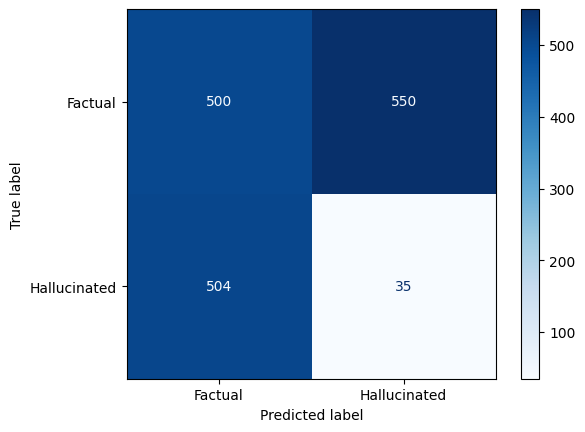

In [285]:
#GMM test results
test_preds = gmm.predict(X_test_scaled)
cm = confusion_matrix(y_test, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Factual', 'Hallucinated'])
disp.plot(cmap=plt.cm.Blues)

### KNN

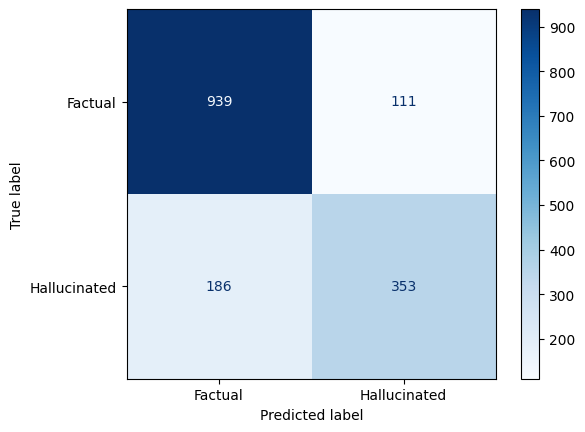

In [286]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=8)
knn.fit(X_train_scaled, y_train)
test_preds = knn.predict(X_test_scaled)
cm = confusion_matrix(y_test, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Factual', 'Hallucinated'])
disp.plot(cmap=plt.cm.Blues)

### Logistic Regression

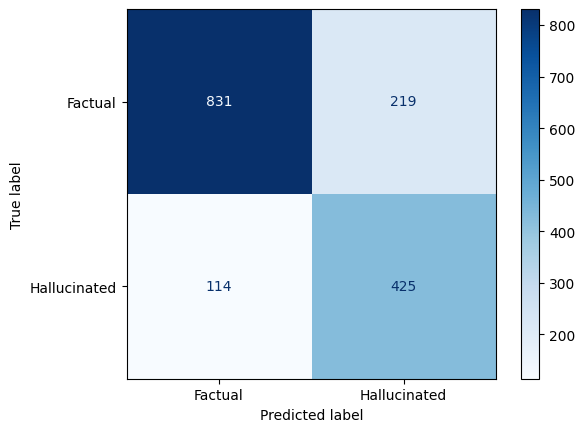

In [287]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(class_weight={0:1, 1:1.7}, random_state=42)
lr.fit(X_train_scaled, y_train)
test_preds = lr.predict(X_test_scaled)
cm = confusion_matrix(y_test, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Factual', 'Hallucinated'])
disp.plot(cmap=plt.cm.Blues)

### Decision Tree and Random Forest

In [288]:
from sklearn.tree import DecisionTreeClassifier\

from sklearn.model_selection import GridSearchCV


param_grid = {
    'max_depth': [5, 10, 20, 30, 50, None],
    'min_samples_split': [5, 10, 20, 30, 50],
    'min_samples_leaf': [1, 2, 3, 4, 5, 10, 20, 30, 50]}

dt = DecisionTreeClassifier(random_state=2) #use first value in each list for now

grid = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1)

grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=2), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 20, 30, 50, None],
                         'min_samples_leaf': [1, 2, 3, 4, 5, 10, 20, 30, 50],
                         'min_samples_split': [5, 10, 20, 30, 50]},
             scoring='f1')

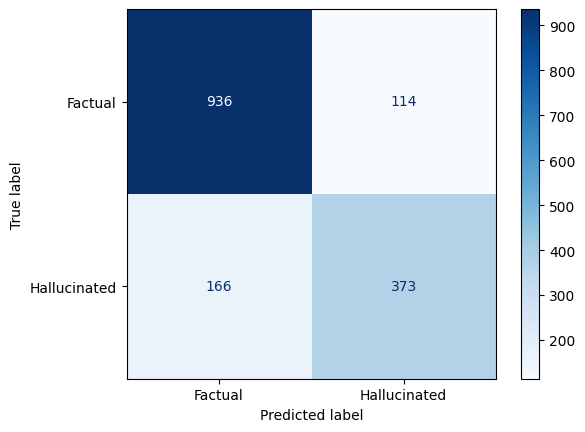

In [289]:
best_dt = grid.best_estimator_

#predict with decision tree
test_preds = best_dt.predict(X_test_scaled)

#confusion matrix for decision tree
cm = confusion_matrix(y_test, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Factual', 'Hallucinated'])
disp.plot(cmap=plt.cm.Blues)

plt.show()

In [290]:
from sklearn.ensemble import RandomForestClassifier

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 20, None],
    'max_features': ['sqrt', 'log2'],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'bootstrap': [True]}

rf = RandomForestClassifier(random_state=2)

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring="f1",
    n_jobs=-1)

grid_rf.fit(X_train_scaled, y_train)


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=2), n_jobs=-1,
             param_grid={'bootstrap': [True], 'max_depth': [5, 10, 20, None],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 5],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200]},
             scoring='f1')

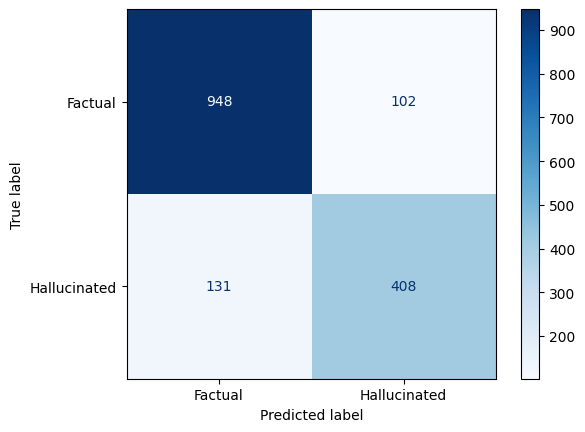

In [291]:
best_rf = grid_rf.best_estimator_

best_rf.fit(X_train_scaled, y_train)
test_preds = best_rf.predict(X_test_scaled)
cm = confusion_matrix(y_test, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Factual', 'Hallucinated'])
disp.plot(cmap=plt.cm.Blues)

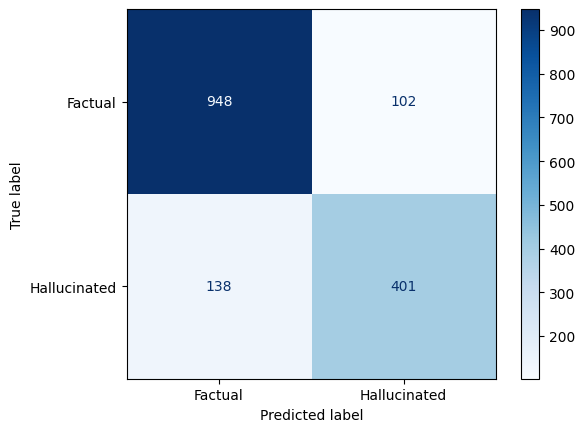

In [292]:
from sklearn.model_selection import RandomizedSearchCV

param_dist_rs = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 20, None],
    'max_features': ['sqrt', 'log2'],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'bootstrap': [True]}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_rs,
    n_iter=20,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    random_state=2)

random_search.fit(X_train, y_train)

best_rs_random = random_search.best_estimator_

best_rs_random.fit(X_train_scaled, y_train)
test_preds = best_rs_random.predict(X_test_scaled)
cm = confusion_matrix(y_test, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Factual', 'Hallucinated'])
disp.plot(cmap=plt.cm.Blues)